In [1]:
# Install libraries 
!pip install seaborn --quiet
!pip install missingno --quiet
!pip install imblearn --quiet
!pip install scikit-learn --quiet

In [2]:
# Import required libraries 
import os 
import sys
import pandas as pd 
import seaborn as sns
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
import warnings

sys.path.append(os.path.abspath(".."))

# Import functions 
import functions.wrangling as wrg
import functions.missing_labs as ml
import functions.eda as eda
import functions.eda_model as em

warnings.filterwarnings("ignore")

In [3]:
# Set working directory (change this to the folder on your system)
os.chdir(r"G:\.shortcut-targets-by-id\1qO0AfYMqzVbXreDMm-gZUvrYXtVZCnDA\CHL8010F2  CPCSSN Dataset") 

In [3]:
# Load and clean datasets

# Define and load file paths 
file_paths = {
    'patient': 'C4MPatient.csv',
    'lab': 'C4MLab.csv',
    'diag': 'C4MEncounterdiagnosis.csv',
    'condition': 'C4MHealthCondition.csv'
}
datasets = wrg.load_csv(file_paths)

# Specify columns to keep from each dataset
columns_to_keep = {
    'patient': ["Patient_ID", "Sex", "BirthYear"],
    'lab': ["Patient_ID", "Name_calc", "TestResult_calc", "PerformedDate"],
    'diag': ["Patient_ID", "DiagnosisText_calc", "DiagnosisCode_calc", "DateCreated"],
    'condition': ["Patient_ID", "DiagnosisText_calc", "DateCreated"]
}
datasets = wrg.select_columns(datasets, columns_to_keep)

# Clean diagnosis data 
diagnosis_cleaning_steps = [
    ('DiagnosisText_calc', 'uppercase'),
    ('DiagnosisCode_calc', 'strip'),
    ('DiagnosisCode_calc', 'dropna'),
    ('DateCreated', 'datetime')
]
datasets['diag'] = wrg.replace_string_nan(datasets['diag'], 'DiagnosisCode_calc')
datasets['diag'] = wrg.preprocess_data(datasets['diag'], diagnosis_cleaning_steps)

In [4]:
# Extract bipolar disorder lab results and summarize patient counts

# Define BD ICD-9 codes and relevant markers
bd_codes = ["296.0", "296.1", "296.4", "296.5", "296.6", "296.7", "296.80", "296.89"]
relevant_markers = ["TOTAL CHOLESTEROL", "HBA1C", "HDL", "FASTING GLUCOSE", "LDL", "INR", "GLUCOSE TOLERANCE"]

# Extract lab results that occur after BD diagnosis
bd_labs_after = wrg.extract_labs_relative_to_diagnosis(
    lab_df=datasets['lab'],
    diag_df=datasets['diag'],
    diagnosis_codes=bd_codes,
    lab_test_names=relevant_markers
)

# Identify each patient's first BD diagnosis date and code
first_dx_info = datasets['diag'].copy()
first_dx_info['DateCreated'] = pd.to_datetime(first_dx_info['DateCreated'], errors='coerce')

# Sort by patient and diagnosis date, and only keep the first record per patient 
first_dx = first_dx_info.sort_values(['Patient_ID', 'DateCreated']).groupby('Patient_ID').first().reset_index()

# Filter to include only patients whose first diagnosis is BD based on ICD-9 codes
first_dx = first_dx[first_dx['DiagnosisCode_calc'].isin(bd_codes)]

# Rename columns 
first_dx = first_dx.rename(columns={
    'DateCreated': 'BD_Diagnosis_Date',
    'DiagnosisCode_calc': 'BD_Code'
})

# Merge diagnosis date and BD code into lab results dataframe 
bd_labs_after = bd_labs_after.merge(
    first_dx[['Patient_ID', 'BD_Diagnosis_Date', 'BD_Code']], 
    on='Patient_ID', 
    how='left'
)

# Drop 'Lab_Timing' column since it's not needed anymore
bd_labs_after = bd_labs_after.drop(columns=['Lab_Timing'])

# Pivot the lab data to create one row per test, per patient, per day
bd_labs_after = bd_labs_after.pivot_table(
    index=['Patient_ID', 'PerformedDate', 'BD_Diagnosis_Date', 'BD_Code'],
    columns='Name_calc',
    values='TestResult_calc',
    aggfunc='first'
).reset_index()

# Sort final lab dataset by patient and test date
bd_labs_after = bd_labs_after.sort_values(by=['Patient_ID', 'PerformedDate'])

# Classify lab timing (before, after, or both relative to diagnosis)
lab_timing_summary, bd_first_clean = wrg.classify_lab_timing(
    lab_df=datasets['lab'],
    diag_df=datasets['diag'],
    diagnosis_codes=bd_codes
)

# Count how many BD patients had additional non-BD diagnoses on the same day 
non_bd_same_day_count = wrg.other_dx_same_day(
    diag_df=datasets['diag'],
    bd_first_clean=bd_first_clean,
    bd_codes=bd_codes
)

# Output patient counts and lab data availability
summary_stats = [
    ("Total BD patients (first-ever diagnosis)", bd_first_clean['Patient_ID'].nunique()),
    ("BD patients with labs after diagnosis", lab_timing_summary[lab_timing_summary['Lab_Data_Timing'] == 'Only after']['Patient_ID'].nunique()),
    ("Number of patients with lab results after diagnosis date", bd_labs_after['Patient_ID'].nunique()),
]

for label, value in summary_stats:
    print(f"{label}: {value}")

# Save to CSV 
bd_labs_after.to_csv("bd_labs_only_after.csv", index=False)

Total BD patients (first-ever diagnosis): 378
BD patients with labs after diagnosis: 195
Number of patients with lab results after diagnosis date: 214


In [5]:
#bd_labs_after.head()

In [6]:
# Column selection and imputation 

# Load bd_labs_after dataset
df = ml.load_data("bd_labs_only_after.csv")

# define metadata columns
meta_cols = [
    "Patient_ID", "PerformedDate", "BD_Diagnosis_Date", 
    "BD_Code", #"DiagnosisText_calc", #"Lab_Timing"
]

# Get lab columns 
lab_cols = ml.get_lab_columns(df, meta_cols)

# Keep all lab columns and impute values for all of them
full_df, full_dropped = ml.impute_labs(
    df, meta_cols, lab_cols, 
    save_prefix="bd_labs_after_cleaned_all", 
    drop_missing=False
)

# Only keep lab columns with less than 50% missing data, then impute values for the columns we keep
reduced_df, reduced_dropped = ml.impute_labs(
df, meta_cols, lab_cols, 
    save_prefix="bd_labs_after_cleaned_reduced", 
    drop_missing=True
)

Loaded dataset with shape: (1196, 11)
Auto-detected lab columns: ['FASTING GLUCOSE', 'GLUCOSE TOLERANCE', 'HBA1C', 'HDL', 'INR', 'LDL', 'TOTAL CHOLESTEROL']
Keeping all lab columns regardless of missingness.
Imputing FASTING GLUCOSE using median (skewness=3.98)
Imputing GLUCOSE TOLERANCE using mean (skewness=nan)
Imputing HBA1C using median (skewness=2.27)
Imputing HDL using median (skewness=1.06)
Imputing INR using mean (skewness=0.62)
Imputing LDL using mean (skewness=0.11)
Imputing TOTAL CHOLESTEROL using mean (skewness=-0.00)
Saved cleaned dataset to bd_labs_after_cleaned_all.csv
Dropping columns with >50% missing: ['FASTING GLUCOSE', 'GLUCOSE TOLERANCE', 'HBA1C', 'HDL', 'INR', 'LDL', 'TOTAL CHOLESTEROL']
Saved cleaned dataset to bd_labs_after_cleaned_reduced.csv


Loaded dataset with shape: (1196, 11)
patient summary
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 352161 entries, 0 to 352160
Data columns (total 3 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   Patient_ID  352161 non-null  int64  
 1   Sex         352121 non-null  object 
 2   BirthYear   352020 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 8.1+ MB
None

lab summary
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8528807 entries, 0 to 8528806
Data columns (total 4 columns):
 #   Column           Dtype 
---  ------           ----- 
 0   Patient_ID       int64 
 1   Name_calc        object
 2   TestResult_calc  object
 3   PerformedDate    object
dtypes: int64(1), object(3)
memory usage: 260.3+ MB
None

diag summary
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12471764 entries, 0 to 12471763
Data columns (total 4 columns):
 #   Column              Dtype         
---  ------              -----     

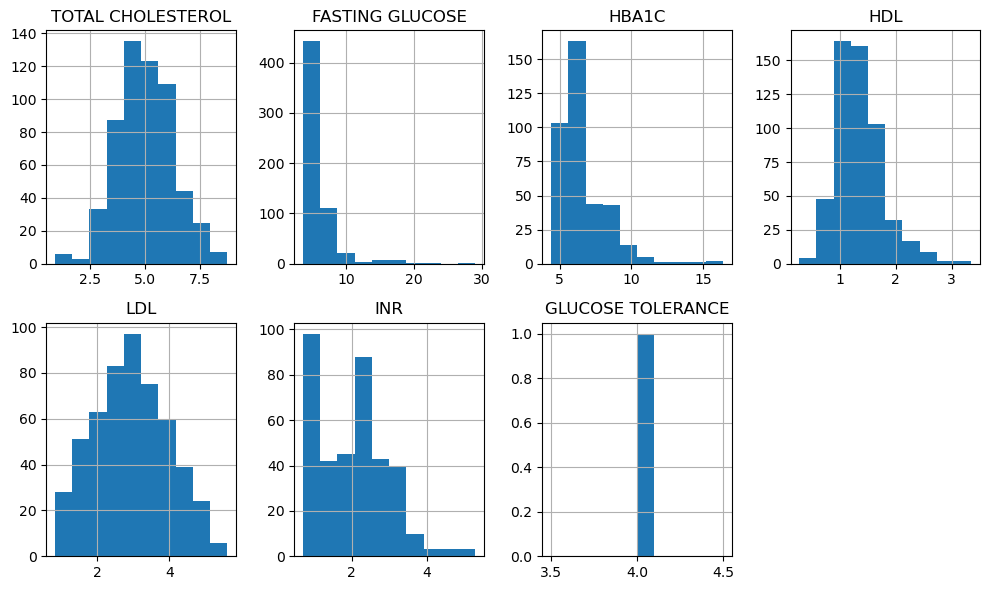


Correlation matrix:
                   TOTAL CHOLESTEROL  FASTING GLUCOSE     HBA1C       HDL  \
TOTAL CHOLESTEROL           1.000000        -0.140201 -0.124462  0.242516   
FASTING GLUCOSE            -0.140201         1.000000  0.846937 -0.174115   
HBA1C                      -0.124462         0.846937  1.000000 -0.224464   
HDL                         0.242516        -0.174115 -0.224464  1.000000   
LDL                         0.861575        -0.204603 -0.228975  0.048691   
INR                         0.208236        -0.204938  0.671633  0.393083   
GLUCOSE TOLERANCE                NaN              NaN       NaN       NaN   

                        LDL       INR  GLUCOSE TOLERANCE  
TOTAL CHOLESTEROL  0.861575  0.208236                NaN  
FASTING GLUCOSE   -0.204603 -0.204938                NaN  
HBA1C             -0.228975  0.671633                NaN  
HDL                0.048691  0.393083                NaN  
LDL                1.000000  0.362634                NaN  
INR     

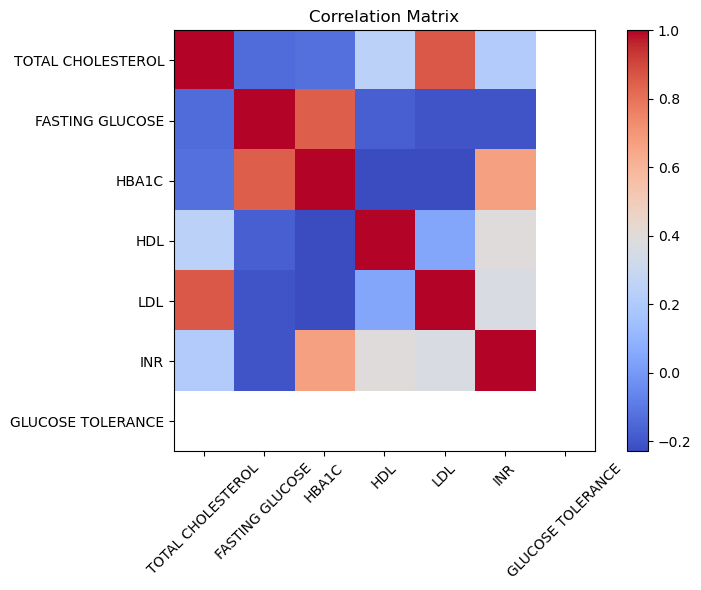


Correlation matrix:
                   TOTAL CHOLESTEROL  FASTING GLUCOSE     HBA1C       HDL  \
TOTAL CHOLESTEROL           1.000000        -0.140201 -0.124462  0.242516   
FASTING GLUCOSE            -0.140201         1.000000  0.846937 -0.174115   
HBA1C                      -0.124462         0.846937  1.000000 -0.224464   
HDL                         0.242516        -0.174115 -0.224464  1.000000   
LDL                         0.861575        -0.204603 -0.228975  0.048691   
INR                         0.208236        -0.204938  0.671633  0.393083   

                        LDL       INR  
TOTAL CHOLESTEROL  0.861575  0.208236  
FASTING GLUCOSE   -0.204603 -0.204938  
HBA1C             -0.228975  0.671633  
HDL                0.048691  0.393083  
LDL                1.000000  0.362634  
INR                0.362634  1.000000  


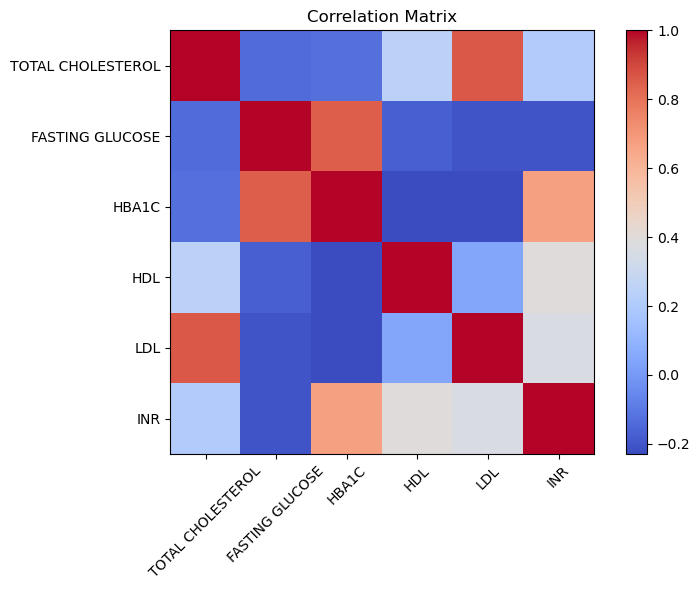

Unique values in GLUCOSE TOLERANCE: [nan  4.]


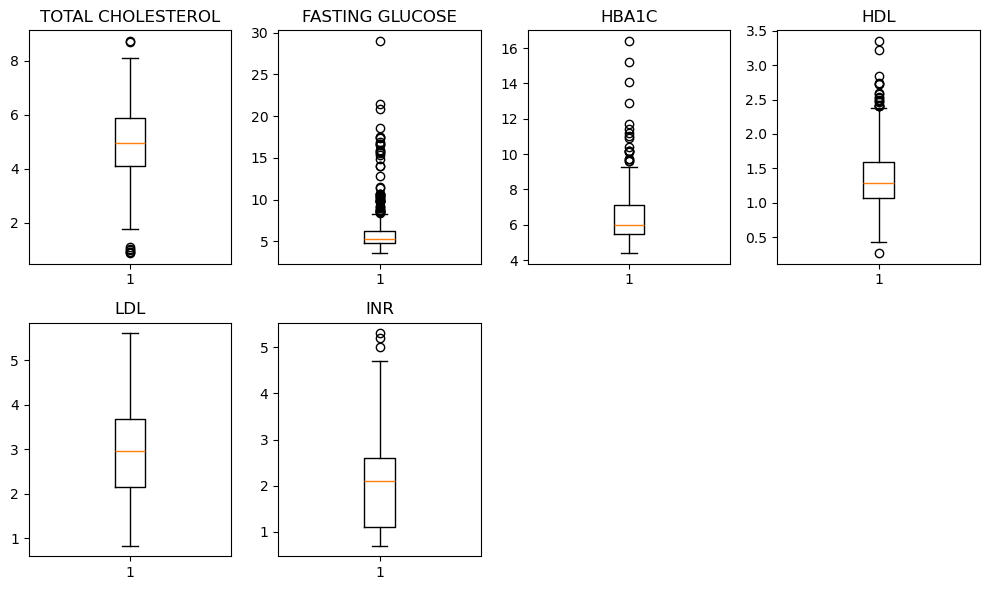

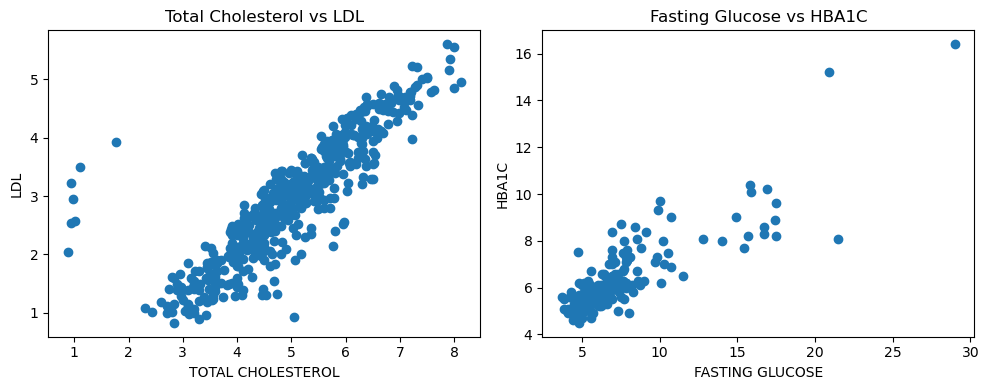

In [7]:
# Load imputed, clean dataset 
#df_two_vars =  ml.load_data("cleaned_dataset_two_vars.csv")
#df_all_vars =  ml.load_data("cleaned_dataset_all_vars.csv")
df_all_vars =  ml.load_data("bd_labs_after_cleaned_reduced.csv")

# Get concise summary of the structure and content of DataFrames
eda.summarize_dataframes(datasets)

# Calculate summary statistics for lab markers
lab_cols_two = ['TOTAL CHOLESTEROL', 'FASTING GLUCOSE']
lab_cols_all = ['TOTAL CHOLESTEROL', 'FASTING GLUCOSE', 'HBA1C', 'HDL', 'LDL', 'INR', 'GLUCOSE TOLERANCE']
numeric_columns = {
    #'two_vars': lab_cols_two,
    'all_vars': lab_cols_all
}
summaries = eda.summarize_numeric_statistics(datasets, numeric_columns)

# Plot histograms for lab markers (all_vars dataset, default 10 bins)
print("Histogram with 10 bins")
eda.plot_histograms(df_all_vars, lab_cols_all)

# Plot correlation matrix for all lab columns
eda.corr_matrix = eda.plot_correlation_matrix(df_all_vars, lab_cols_all)

# Correlation matrix excluding GLUCOSE TOLERANCE
lab_cols_reduced = ['TOTAL CHOLESTEROL', 'FASTING GLUCOSE', 'HBA1C', 'HDL', 'LDL', 'INR']
corr_matrix_reduced = eda.plot_correlation_matrix(df_all_vars, lab_cols_reduced)

# Check why GLUCOSE TOLERANCE has NaN correlations
eda.check_unique_values(df_all_vars, 'GLUCOSE TOLERANCE')

# Plot boxplots to analyze outliers
eda.plot_boxplots(df_all_vars, lab_cols_reduced)

# Plot scatter pairs for high-correlation combinations
eda.plot_scatter_pairs(df_all_vars, [
    ('TOTAL CHOLESTEROL', 'LDL', 'Total Cholesterol vs LDL'),
    ('FASTING GLUCOSE', 'HBA1C', 'Fasting Glucose vs HBA1C')
])